In [1]:
library(tidyverse)
library(nycflights13)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning messages:
1: package ‘tidyverse’ was built under R version 4.5.2 
2: package ‘ggplot2’ was built under R version 4.5.2 
3: package ‘tibble’ was built under R version 4.5.2 
4: package ‘tidyr’ was built under R version 4.5.2 
5: package ‘readr’ was built under R version 4.5.2 
6: package ‘purrr’ was built under R version 4.5.2 
7: package ‘dplyr’ was built under R version 4.5.2 
8: package ‘stringr’ was built under R version 4.5.2 
9: package ‘lubridate’ was built under R version 4.5.2 
Warning message:
package ‘nycflights13’ was built under R version 4.5.2 


In [2]:
#handlie the JSON file
install.packages("jsonlite")

Installing package into ‘C:/Users/ganes/AppData/Local/R/win-library/4.5’
(as ‘lib’ is unspecified)


trying URL 'https://cran.rstudio.com/bin/windows/contrib/4.5/jsonlite_2.0.0.zip'
Content type 'application/zip' length 1110772 bytes (1.1 MB)
downloaded 1.1 MB



package ‘jsonlite’ successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\ganes\AppData\Local\Temp\Rtmp6zFucP\downloaded_packages


In [ ]:
library(jsonlite)
setwd("C:\\Users\\ganes\\Downloads\\R_test\\testing")
flights_data <- flights |> slice(1:10)
write_json(flights_data,"flights.json")
read_json("flights.json")
fromJSON("flights.json") #to read proper format.

   year month day dep_time sched_dep_time dep_delay arr_time sched_arr_time
1  2013     1   1      517            515         2      830            819
2  2013     1   1      533            529         4      850            830
3  2013     1   1      542            540         2      923            850
4  2013     1   1      544            545        -1     1004           1022
5  2013     1   1      554            600        -6      812            837
6  2013     1   1      554            558        -4      740            728
7  2013     1   1      555            600        -5      913            854
8  2013     1   1      557            600        -3      709            723
9  2013     1   1      557            600        -3      838            846
10 2013     1   1      558            600        -2      753            745
   arr_delay carrier flight tailnum origin dest air_time distance hour minute
1         11      UA   1545  N14228    EWR  IAH      227     1400    5     15
2       

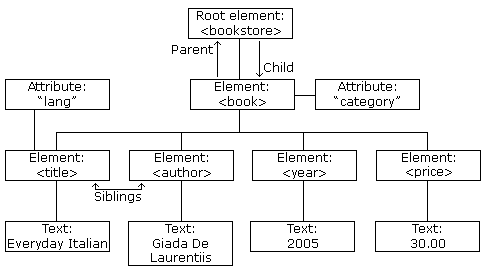

In [ ]:
flights_small <- flights |> select(year,month,day,carrier,flight, origin,dest) |> slice(1:10)
install.packages("xml2")

Installing package into ‘C:/Users/ganes/AppData/Local/R/win-library/4.5’
(as ‘lib’ is unspecified)


trying URL 'https://cran.rstudio.com/bin/windows/contrib/4.5/xml2_1.5.2.zip'
Content type 'application/zip' length 1621470 bytes (1.5 MB)
downloaded 1.5 MB



package ‘xml2’ successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\ganes\AppData\Local\Temp\Rtmp6zFucP\downloaded_packages


In [15]:
library(xml2)
flights_small
root <- xml_new_root("flights")
#add the child to teh root
for(i in 1:nrow(flights_small)){
  flight_node <- xml_add_child(root,"flight")
  xml_add_child(flight_node,"year",flights_small$year[i])
  xml_add_child(flight_node,"month",flights_small$month[i])
  xml_add_child(flight_node,"day",flights_small$day[i])
  xml_add_child(flight_node,"carrier",flights_small$carrier[i])
  xml_add_child(flight_node,"flight",flights_small$flight[i])
  xml_add_child(flight_node,"origin",flights_small$origin[i])
  xml_add_child(flight_node,"dest",flights_small$dest[i])
}
write_xml(root,"flights.xml")

In [35]:
xml_data <- read_xml("flights.xml")
xml_data
xml_list<-as_list(xml_data)
df<-as_tibble(xml_list) |> unnest_wider(flights) |> unnest_longer(everything())
df

# A tibble: 10 × 7
   year  month day   carrier flight origin dest 
   <chr> <chr> <chr> <chr>   <chr>  <chr>  <chr>
 1 2013  1     1     UA      1545   EWR    IAH  
 2 2013  1     1     UA      1714   LGA    IAH  
 3 2013  1     1     AA      1141   JFK    MIA  
 4 2013  1     1     B6      725    JFK    BQN  
 5 2013  1     1     DL      461    LGA    ATL  
 6 2013  1     1     UA      1696   EWR    ORD  
 7 2013  1     1     B6      507    EWR    FLL  
 8 2013  1     1     EV      5708   LGA    IAD  
 9 2013  1     1     B6      79     JFK    MCO  
10 2013  1     1     AA      301    LGA    ORD  

In [37]:
#YAML file
install.packages("yaml")
library(yaml)

Installing package into ‘C:/Users/ganes/AppData/Local/R/win-library/4.5’
(as ‘lib’ is unspecified)


trying URL 'https://cran.rstudio.com/bin/windows/contrib/4.5/yaml_2.3.12.zip'
Content type 'application/zip' length 124909 bytes (121 KB)
downloaded 121 KB



package ‘yaml’ successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\ganes\AppData\Local\Temp\Rtmp6zFucP\downloaded_packages


Warning message:
package ‘yaml’ was built under R version 4.5.3 


In [42]:
flight_list <- split(
  flights_small,
  seq(nrow(flights_small))
)
flight_list
#write a yaml file
write_yaml(
  flight_list,
  "flights.yaml"
)
#View the YAML file.
cat(readLines("flights.yaml"), sep = "\n")
#read the yaml file
read_yaml("flights.yaml")

'1':
  year: 2013
  month: 1
  day: 1
  carrier: UA
  flight: 1545
  origin: EWR
  dest: IAH
'2':
  year: 2013
  month: 1
  day: 1
  carrier: UA
  flight: 1714
  origin: LGA
  dest: IAH
'3':
  year: 2013
  month: 1
  day: 1
  carrier: AA
  flight: 1141
  origin: JFK
  dest: MIA
'4':
  year: 2013
  month: 1
  day: 1
  carrier: B6
  flight: 725
  origin: JFK
  dest: BQN
'5':
  year: 2013
  month: 1
  day: 1
  carrier: DL
  flight: 461
  origin: LGA
  dest: ATL
'6':
  year: 2013
  month: 1
  day: 1
  carrier: UA
  flight: 1696
  origin: EWR
  dest: ORD
'7':
  year: 2013
  month: 1
  day: 1
  carrier: B6
  flight: 507
  origin: EWR
  dest: FLL
'8':
  year: 2013
  month: 1
  day: 1
  carrier: EV
  flight: 5708
  origin: LGA
  dest: IAD
'9':
  year: 2013
  month: 1
  day: 1
  carrier: B6
  flight: 79
  origin: JFK
  dest: MCO
'10':
  year: 2013
  month: 1
  day: 1
  carrier: AA
  flight: 301
  origin: LGA
  dest: ORD


$`1`
$`1`$year
[1] 2013

$`1`$month
[1] 1

$`1`$day
[1] 1

$`1`$carrier
[1] "UA"

$`1`$flight
[1] 1545

$`1`$origin
[1] "EWR"

$`1`$dest
[1] "IAH"


$`2`
$`2`$year
[1] 2013

$`2`$month
[1] 1

$`2`$day
[1] 1

$`2`$carrier
[1] "UA"

$`2`$flight
[1] 1714

$`2`$origin
[1] "LGA"

$`2`$dest
[1] "IAH"


$`3`
$`3`$year
[1] 2013

$`3`$month
[1] 1

$`3`$day
[1] 1

$`3`$carrier
[1] "AA"

$`3`$flight
[1] 1141

$`3`$origin
[1] "JFK"

$`3`$dest
[1] "MIA"


$`4`
$`4`$year
[1] 2013

$`4`$month
[1] 1

$`4`$day
[1] 1

$`4`$carrier
[1] "B6"

$`4`$flight
[1] 725

$`4`$origin
[1] "JFK"

$`4`$dest
[1] "BQN"


$`5`
$`5`$year
[1] 2013

$`5`$month
[1] 1

$`5`$day
[1] 1

$`5`$carrier
[1] "DL"

$`5`$flight
[1] 461

$`5`$origin
[1] "LGA"

$`5`$dest
[1] "ATL"


$`6`
$`6`$year
[1] 2013

$`6`$month
[1] 1

$`6`$day
[1] 1

$`6`$carrier
[1] "UA"

$`6`$flight
[1] 1696

$`6`$origin
[1] "EWR"

$`6`$dest
[1] "ORD"


$`7`
$`7`$year
[1] 2013

$`7`$month
[1] 1

$`7`$day
[1] 1

$`7`$carrier
[1] "B6"

$`7`$flight
[1] 507

$`7`$